# CDR: `BROKE` Engine Nitrous Conversion

In [1]:
import numpy as np
import handcalcs.render
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
from scipy.interpolate import interpn
from turborocket.transient.start_up import MainEngine
from turborocket.fluids.fluids import IncompressibleFluid
import matplotlib.pyplot as plt


Author: Elias Aoubala

Date: 15/02/2026

## 1 - Background

This document contains the authors analysis for the sizing/modification of the BROKE series of engines, as developed and lead by Khue. The original BROKE engine was sized for LOX/IPA, however for the Race To Space competition, only Nitrous/IPA will be possible.

As such, this document aims to evaluate the expected performance of the engine, using the exact same injector - just this time supplied with Nitrous/IPA. This document is not aimed to be comprehensive, but just to be a quick and dirty analysis to see if the present engine can be used on an `as-is` basis.

## 2 - High Level functional Parameters

The key high level functional paramaters we will need to be able to perform this analysis, is the criticaly the throat area and injector dimensions.

These parameters will be used to instantiate a turborocket object, from which we can assess the systems performance from.

### 2.1 - Injector Dimensions

Based on Khue's PDR submission, the following dimensions are found:

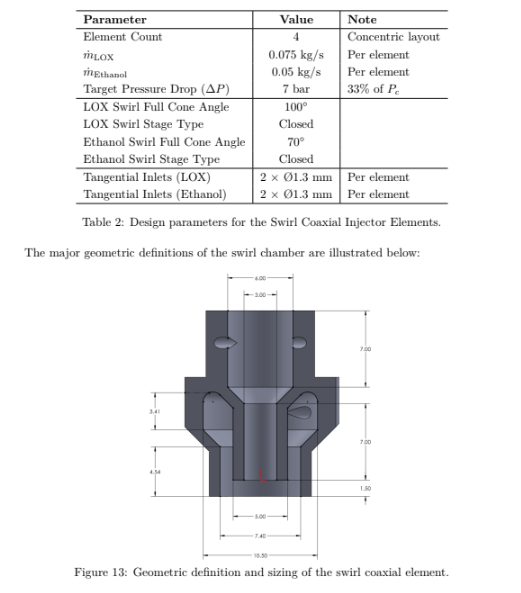

The injector head consists of a total of 4 elements, each having two oxidiser and fuel holes each. This as a result, yields the following.

In [2]:
%%render sci_not param

N_orif = 2

d_ox = 1.3e-3 # m
d_fu = 1.3e-3 # m

<IPython.core.display.Latex object>

As there are 4 injector elements in total, we can evaluate for the total effective orifice area accordingly.

In [3]:
%%render sci_not

N_element = 4

A_ox = N_element * N_orif * np.pi * (d_ox/2)**2 # m**2

A_fu = N_element * N_orif * np.pi * (d_fu/2)**2 # m**2

<IPython.core.display.Latex object>

### 2.2 - Main Engine Dimensions

For the throat dimensions, we can extract the parameters based on a heat-flux plot Khue presented in his PDR (results deriving from RPA).

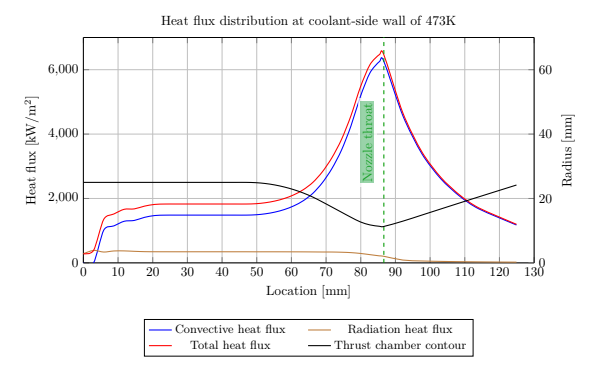

From this plot, we can approximate the throat radius to be about 12 mm. Using this, we can deriving the throat area accordingly.

In [4]:
%%render sci_not

r_throat = 12e-3 # m

A_throat = np.pi * (r_throat) **2 # m**2

<IPython.core.display.Latex object>

In addition, based on the plot, we can estimate the exit nozzle radius to be ~ 22 mm, which we will use accordingly.

In [5]:
%%render sci_not

r_exit = 22e-3 # m

A_exit = np.pi * (r_exit) **2 # m**2

<IPython.core.display.Latex object>

### 2.3 - Assumed Performance Parameters

Inorder to finally assess the engines performance, we need to have an estimated idea of the engines expected c* efficiency and injector discharge coefficients.

These are challenging to estimate, as they are primarily experimentally driven - but in this case, we can estimate them.

**PLEASE NOTE: Fintan has taken on the action to verify if glasgow has also done swirl injectors to derive discharge coefficients.**

In [89]:
%%render param

Cd_ox = 0.3

Cd_fu = 0.2

eta_c = 0.92

<IPython.core.display.Latex object>

## 3 - `turboRocket` Object Instantation

Now that we have derived our key functional parameters, we can now instantiate our `MainEngine` object from TurboRocket, to assess the system performance at varying inlet conditions.

Firstly, we need to define our propellants that we will be using with the engine.

In [90]:
%%render params sci_not

Ox = "N2O"
Fu = "C3H8O,2propanol"

<IPython.core.display.Latex object>

We can now instantiate our main engine object now. We can for now, just pass random parameters for the MR and Pcc

In [91]:
BROKE = MainEngine(
    Ox=Ox, Fu=Fu, Pcc=10e5, MR=3
)

We now instantiate our cantera combustion file for Nitrous/IPA similarly.

In [92]:
BROKE.comb_object(combustion_file="n2o_ipa.yaml")

We can now set our geometric parameters of the engine accordingly:

In [93]:
BROKE.set_geometry(a_ox = A_ox, a_fu = A_fu, a_cc = A_throat, a_e = A_exit)

We also need to set our relevant stochastic parameters, being the discharge coefficients and expected c* efficiency.

**NOTE: These are currently assumed discharge coefficients and C\* efficiencies - this is to be investigated based on the results to be produced by Fintan**

In [94]:
BROKE.set_stochastic_parameters(Cd_o = Cd_ox, Cd_f=Cd_fu, eta_c=eta_c)

We can now do our sensitivity study!

## 4 - Sensitivity Study

For our sensitivity study, we will iterate through a range of injector inlet conditions, to see if there is an operating box that can be achieved for the engine.

In this case, we will do this by performing a for-loop on a mesh grid of different oxidiser and fuel pressures - and use the `solve_perturb_ss` function to evaluate for the condition.

We will evaluate Injector pressures based on Buxtons capabilities, which will be from 50 Bar to 70 Bar, on both the oxidiser and Fuel.

### 4.1 - Defining Key Fluid Properties

For this analysis, we will only assume the IPA remains constant density, with the Nitrous having the ability to change.

In [95]:
%%render param sci_not

rho_ipa = 786 # kg/m**3

<IPython.core.display.Latex object>

### 4.2 - Setting up our Design of Experiment

We can now setup our mesh grid of points for the evaluation range.

In [99]:
N_points = 25

p_ox_array = np.linspace(40, 60, N_points) * 1e5
p_fu_array = np.linspace(20, 60, N_points) * 1e5

p_ox_array, p_fu_array = np.meshgrid(p_ox_array, p_fu_array)

### 4.3 - Performing our Loop

Before we perform our loop, we need to define our arrays for storing our results. In this case, the key results we care about are the injector conditions, thrust and engine chamber conditions (temperature and pressure).

We will appropriately create our arrays for this.

In [100]:
F_array = np.zeros([N_points, N_points])
P_cc_array = np.zeros([N_points, N_points])
T_cc_array = np.zeros([N_points, N_points])
ox_stiff_array = np.zeros([N_points, N_points])
fu_stiff_array = np.zeros([N_points, N_points])

m_dot_ox_array = np.zeros([N_points, N_points])
m_dot_fu_array = np.zeros([N_points, N_points])

We can now do our for loop accordingly.

In [ ]:
for idx, value in np.ndenumerate(p_ox_array):
    
    p_ox = p_ox_array[idx]
    p_fu = p_fu_array[idx]
    
    liq_fu = IncompressibleFluid(rho=rho_ipa, P=p_fu)
    liq_ox = IncompressibleFluid(rho=CP.PropsSI("D", "P", p_ox, "Q", 0, "NitrousOxide"), P=p_ox)
    
    dic = BROKE.solve_perturb_ss(fu_in=liq_fu, ox_in=liq_ox)
    
    # we then store our data accordingly.
    F_array[idx] = dic["F"]
    T_cc_array[idx] = dic["T_o"]
    P_cc_array[idx] = dic["P_cc"]
    
    ox_stiff_array[idx] = dic["ox_stiffness"]
    fu_stiff_array[idx] = dic["fu_stiffness"]
    
    
    m_dot_fu_array[idx] = dic["m_dot_f"]
    m_dot_ox_array[idx] = dic["m_dot_o"]
    
    print(f"Done: {idx}, p_ox: {p_ox/1e5:.1f}, p_fu: {p_fu/1e5:.1f}")

We can now plot our results

## 5 - Results

The following contour plots illustrate the engines expected performance using Nitrous/IPA.

### 5.1 - Injector Stiffness

A minimum injector stiffness of 15% has been highlighted with a contour to illustrate this point.

Text(0.5, 1.0, 'Oxidiser Side Injector Stiffness')

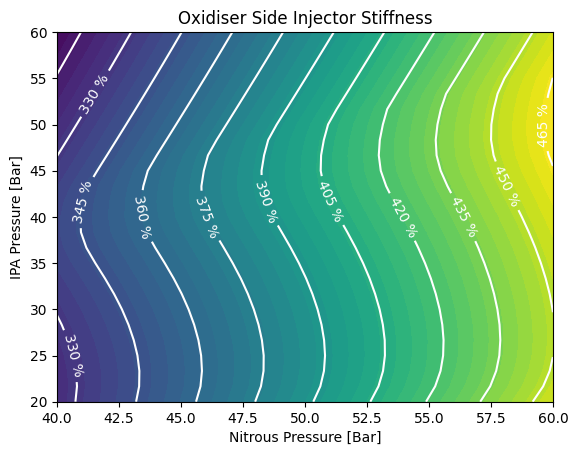

In [102]:
plt.contourf(p_ox_array/1e5, p_fu_array/1e5, ox_stiff_array, levels=50)

k = plt.contour(p_ox_array/1e5, p_fu_array/1e5, ox_stiff_array*100, levels=10, colors="w")

plt.clabel(k, fmt="%d %%")

plt.xlabel("Nitrous Pressure [Bar]")
plt.ylabel("IPA Pressure [Bar]")
plt.title("Oxidiser Side Injector Stiffness")

Text(0.5, 1.0, 'Fuel Side Injector Stiffness')

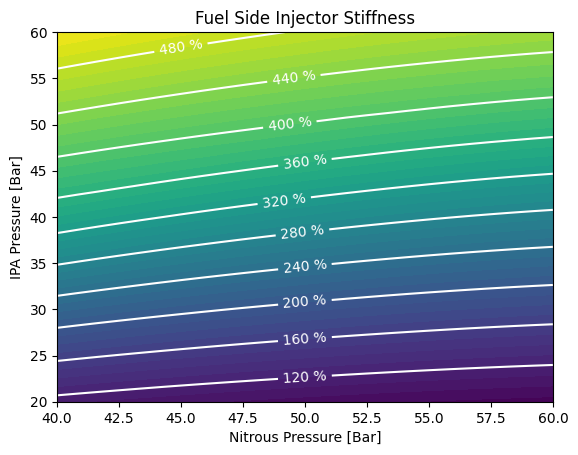

In [103]:
plt.contourf(p_ox_array/1e5, p_fu_array/1e5, fu_stiff_array, levels=50)

k = plt.contour(p_ox_array/1e5, p_fu_array/1e5, fu_stiff_array*100, levels=10, colors="w")

plt.clabel(k, fmt="%d %%")

plt.xlabel("Nitrous Pressure [Bar]")
plt.ylabel("IPA Pressure [Bar]")
plt.title("Fuel Side Injector Stiffness")

### 5.2 - Chamber Conditions

Text(0.5, 1.0, 'Combustion Chamber Pressure')

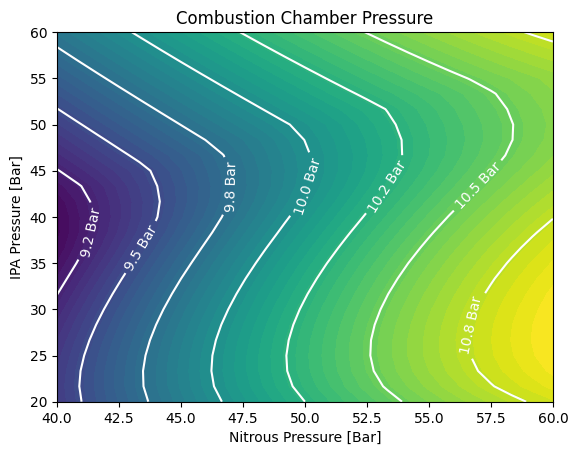

In [104]:
plt.contourf(p_ox_array/1e5, p_fu_array/1e5, P_cc_array/1e5, levels=50)

k = plt.contour(p_ox_array/1e5, p_fu_array/1e5, P_cc_array/1e5, levels=7, colors="w")

plt.clabel(k, fmt="%.1f Bar")

plt.xlabel("Nitrous Pressure [Bar]")
plt.ylabel("IPA Pressure [Bar]")
plt.title("Combustion Chamber Pressure")

Text(0.5, 1.0, 'Combustion Chamber Temperature')

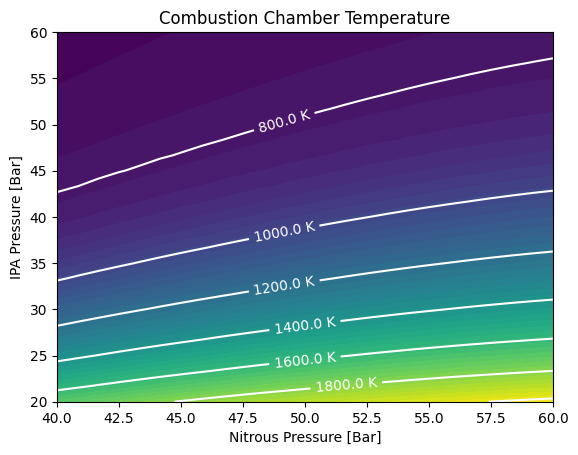

In [105]:
plt.contourf(p_ox_array/1e5, p_fu_array/1e5, T_cc_array - 273.15, levels=50)

k = plt.contour(p_ox_array/1e5, p_fu_array/1e5, T_cc_array - 273.15, levels=7, colors="w")

plt.clabel(k, fmt="%.1f K")

plt.xlabel("Nitrous Pressure [Bar]")
plt.ylabel("IPA Pressure [Bar]")
plt.title("Combustion Chamber Temperature")

### 5.3 - Engine Mass-Flow Rates and Mixture Ratio

Text(0.5, 1.0, 'Injector Mixture Ratio')

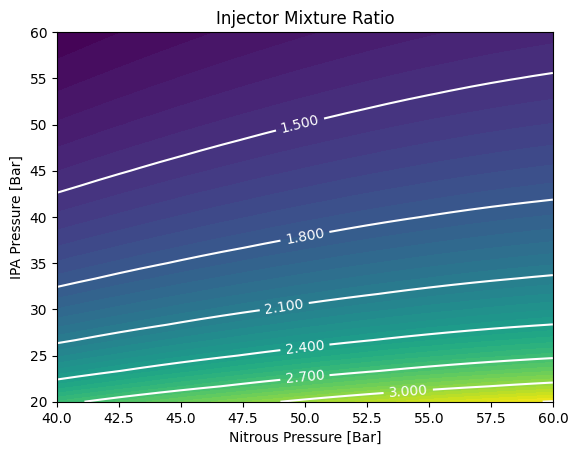

In [106]:
plt.contourf(p_ox_array/1e5, p_fu_array/1e5, m_dot_ox_array/m_dot_fu_array, levels=50)

k = plt.contour(p_ox_array/1e5, p_fu_array/1e5, m_dot_ox_array/m_dot_fu_array, levels=7, colors="w")

plt.clabel(k, fmt="%.3f")

plt.xlabel("Nitrous Pressure [Bar]")
plt.ylabel("IPA Pressure [Bar]")
plt.title("Injector Mixture Ratio")

Text(0.5, 1.0, 'Total Mass Flow Rates')

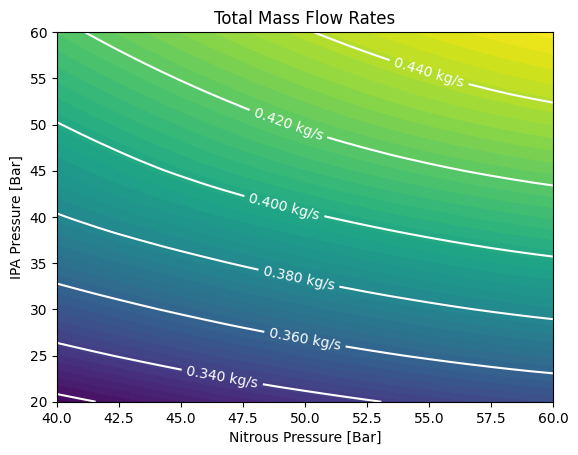

In [107]:
plt.contourf(p_ox_array/1e5, p_fu_array/1e5, m_dot_fu_array + m_dot_ox_array, levels=50)

k = plt.contour(p_ox_array/1e5, p_fu_array/1e5, m_dot_fu_array + m_dot_ox_array, levels=7, colors="w")

plt.clabel(k, fmt="%.3f kg/s")

plt.xlabel("Nitrous Pressure [Bar]")
plt.ylabel("IPA Pressure [Bar]")
plt.title("Total Mass Flow Rates")

### 5.4 - Engine Thrust

Text(0.5, 1.0, 'Engine Thrust')

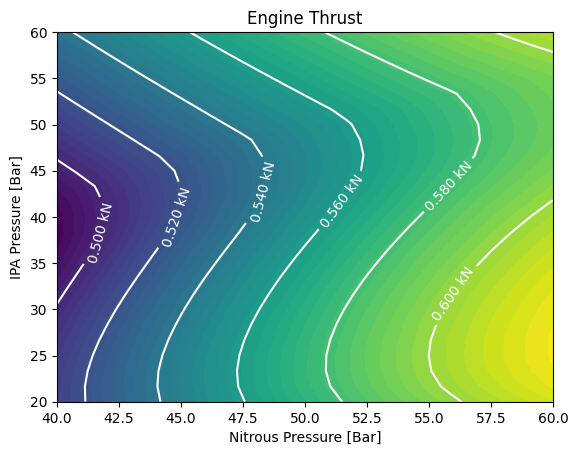

In [108]:
plt.contourf(p_ox_array/1e5, p_fu_array/1e5, F_array, levels=50)

k = plt.contour(p_ox_array/1e5, p_fu_array/1e5, F_array/1e3, levels=7, colors="w")

plt.clabel(k, fmt="%.3f kN")

plt.xlabel("Nitrous Pressure [Bar]")
plt.ylabel("IPA Pressure [Bar]")
plt.title("Engine Thrust")